# In this particular session, we will build different models on the Training Data and then go on to check the accuracy (or error) on the training and test data. The model which performs the best on the test data is an optimum model for us.

# Case Study - We are going to analyse and predict Sales of a particular brick and mortar retail store. The data that we have ranges from 2000 to 2015.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings("ignore")

## Read the data from the '.csv' file as a monthly Time Series.

In [2]:
df = pd.read_csv('Sales.csv')
df.head()

,RetailSales
0,2585
1,3368
2,3210
3,3111
4,3756


## Creating the Time Stamps and adding to the data frame to make it a Time Series Data

In [3]:
187/12

15.583333333333334

In [4]:
.583333333333334 * 12

7.000000000000009

In [5]:
date = pd.date_range(start='1/1/2000', end='8/1/2015', freq='M')
date

DatetimeIndex(['2000-01-31', '2000-02-29', '2000-03-31', '2000-04-30',
               '2000-05-31', '2000-06-30', '2000-07-31', '2000-08-31',
               '2000-09-30', '2000-10-31',
               ...
               '2014-10-31', '2014-11-30', '2014-12-31', '2015-01-31',
               '2015-02-28', '2015-03-31', '2015-04-30', '2015-05-31',
               '2015-06-30', '2015-07-31'],
              dtype='datetime64[ns]', length=187, freq='ME')

In [6]:
# Adding the time stamp to the data frame
df['Time_Stamp'] = pd.DataFrame(date)
df.head()

,RetailSales,Time_Stamp
0,2585,2000-01-31
1,3368,2000-02-29
2,3210,2000-03-31
3,3111,2000-04-30
4,3756,2000-05-31


In [7]:
df.tail()

,RetailSales,Time_Stamp
182,1818,2015-03-31
183,2262,2015-04-30
184,2612,2015-05-31
185,2967,2015-06-30
186,3179,2015-07-31


In [8]:
df.set_index('Time_Stamp',inplace=True)
df.head()

,RetailSales
Time_Stamp,
2000-01-31,2585
2000-02-29,3368
2000-03-31,3210
2000-04-30,3111
2000-05-31,3756


## Plot the Time Series to understand the behaviour of the data.

In [9]:
# The following code is to set the subsequent figure sizes

from pylab import rcParams
rcParams['figure.figsize'] = 20,4

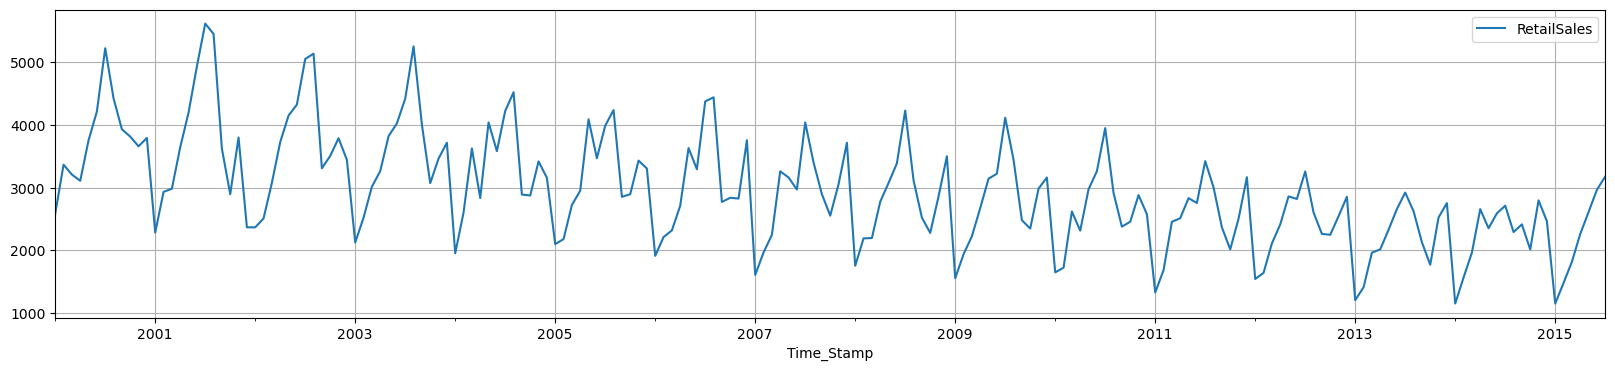

In [10]:
df.plot()
plt.grid();

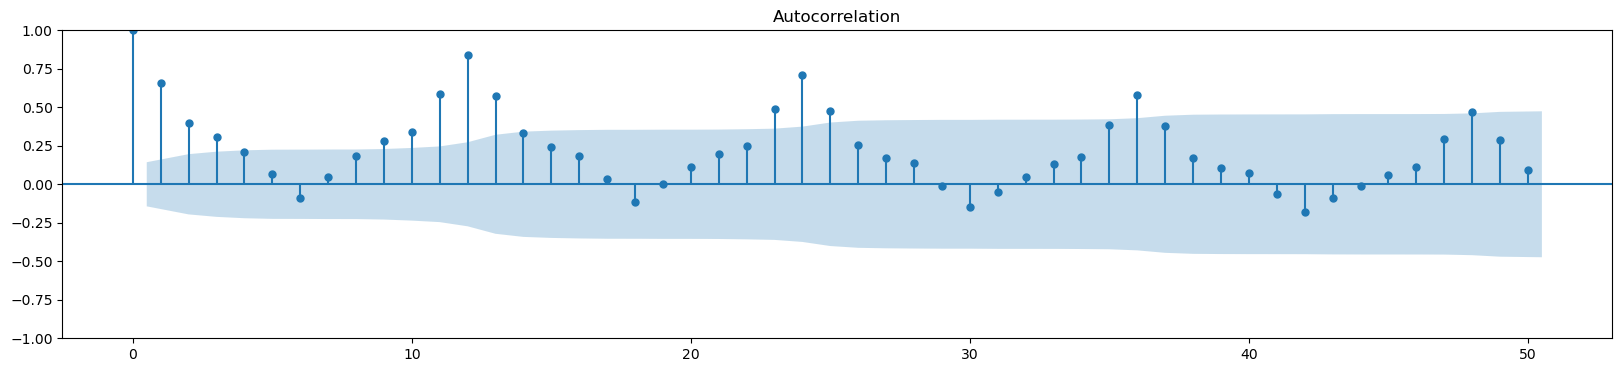

In [12]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(df['RetailSales'],lags=50)
plt.show()

We can see that there is a slight downward trend with a seasonal pattern associated as well.

## Check the basic measures of descriptive statistics

In [ ]:
df.describe()

The basic measures of descriptive statistics tell us how the Sales have varied across years. But remember, for this measure of descriptive statistics we have averaged over the whole data without taking the time component into account.

## Plot a boxplot to understand the spread of accidents across different years and within different months across years.

### Yearly Boxplot

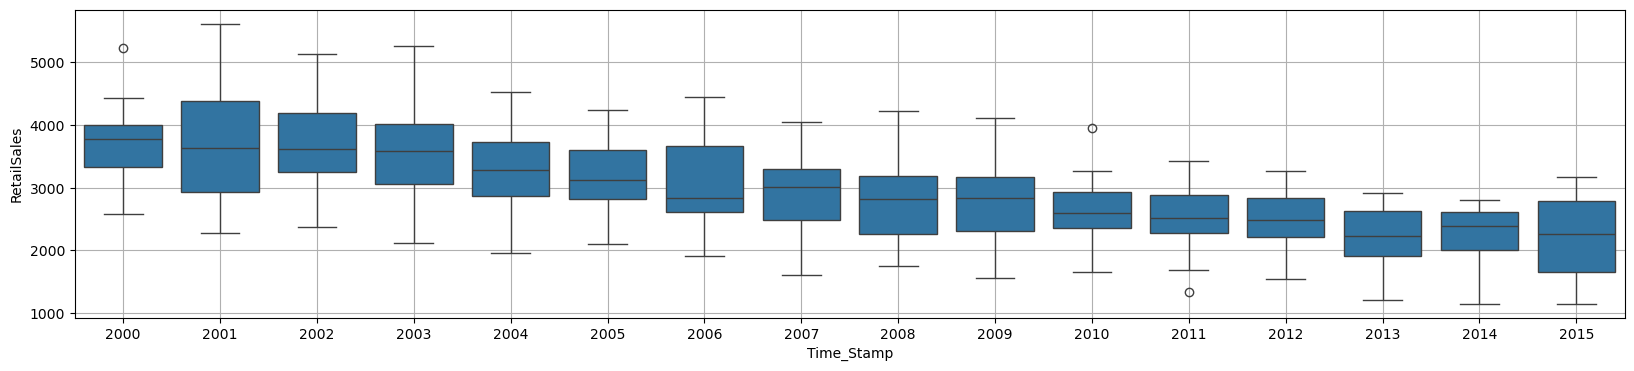

In [13]:
sns.boxplot(x = df.index.year,y = df['RetailSales'])
plt.grid();

The yearly boxplots also shows that the Sales have decreased towards the last few years.

### Monthly Plot

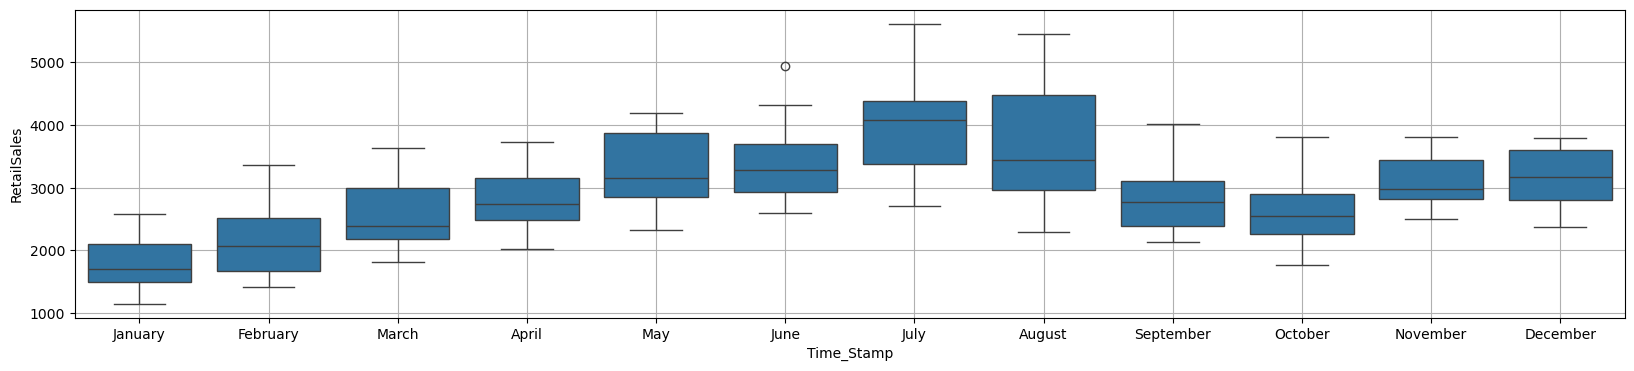

In [14]:
sns.boxplot(x = df.index.month_name(),y = df['RetailSales'])
plt.grid();

There is a clear distinction of 'RetailSales' within different months spread across various years. The highest such numbers are being recorded in the month of July-August across various years.

## Plot a time series monthplot to understand the spread of accidents across different years and within different months across years.

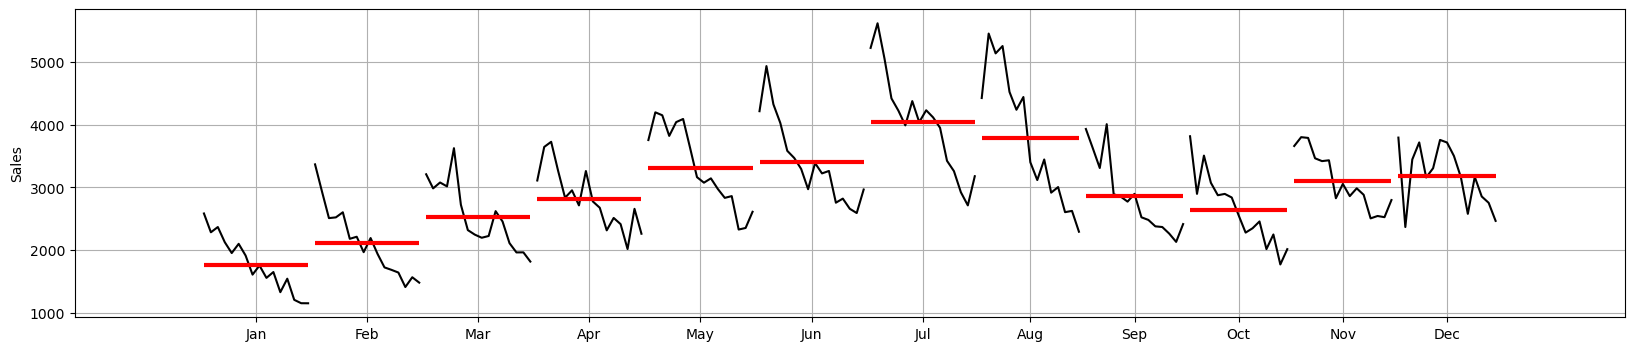

In [15]:
from statsmodels.graphics.tsaplots import month_plot

month_plot(df['RetailSales'],ylabel='Sales')
plt.grid();

This plot shows us the behaviour of the Time Series ('RetailSales' in this case) across various months. The red line is the median value.

## Plot a graph of monthly RetailSales across years.

In [16]:
monthly_sales_across_years = pd.pivot_table(df, values = 'RetailSales', columns = df.index.month, index = df.index.year)
monthly_sales_across_years

Time_Stamp,1,2,3,4,5,6,7,8,9,10,11,12
Time_Stamp,,,,,,,,,,,,
2000,2585.0,3368.0,3210.0,3111.0,3756.0,4216.0,5225.0,4426.0,3932.0,3816.0,3661.0,3795.0
2001,2285.0,2934.0,2985.0,3646.0,4198.0,4935.0,5618.0,5454.0,3624.0,2898.0,3802.0,2369.0
2002,2369.0,2511.0,3079.0,3728.0,4151.0,4326.0,5054.0,5138.0,3310.0,3508.0,3790.0,3446.0
2003,2127.0,2523.0,3017.0,3265.0,3822.0,4027.0,4420.0,5255.0,4009.0,3074.0,3465.0,3718.0
2004,1954.0,2604.0,3626.0,2836.0,4042.0,3584.0,4225.0,4523.0,2892.0,2876.0,3420.0,3159.0
2005,2101.0,2181.0,2724.0,2954.0,4092.0,3470.0,3990.0,4239.0,2855.0,2897.0,3433.0,3307.0
2006,1914.0,2214.0,2320.0,2714.0,3633.0,3295.0,4377.0,4442.0,2774.0,2840.0,2828.0,3758.0
2007,1610.0,1968.0,2248.0,3262.0,3164.0,2972.0,4041.0,3402.0,2898.0,2555.0,3056.0,3717.0
2008,1755.0,2193.0,2198.0,2777.0,3076.0,3389.0,4231.0,3118.0,2524.0,2280.0,2862.0,3502.0


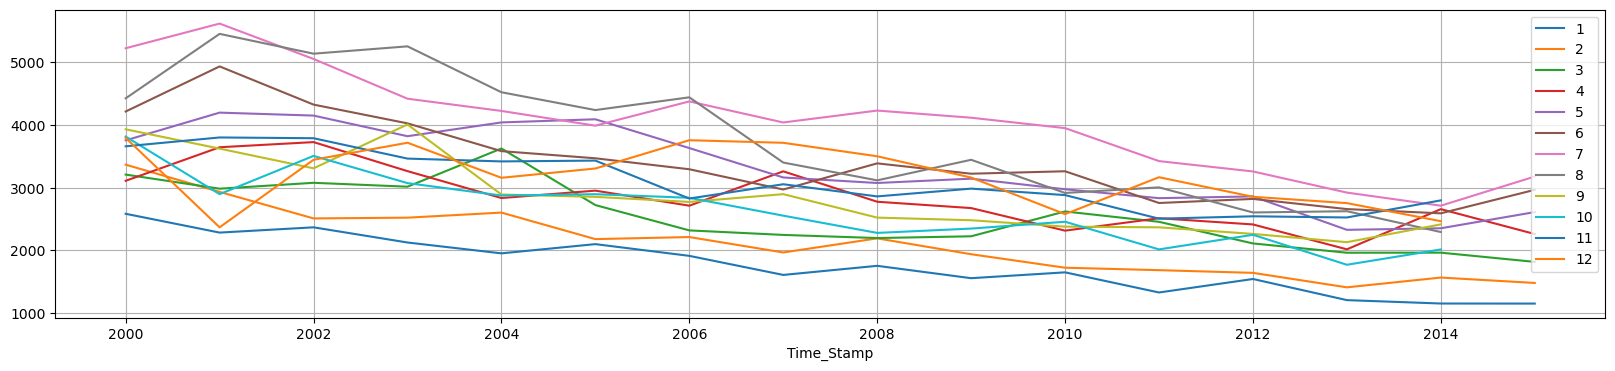

In [17]:
monthly_sales_across_years.plot()
plt.grid()
plt.legend(loc='best');

## Decompose the Time Series and plot the different components.

In [18]:
from    statsmodels.tsa.seasonal import   seasonal_decompose

### Additive Decomposition

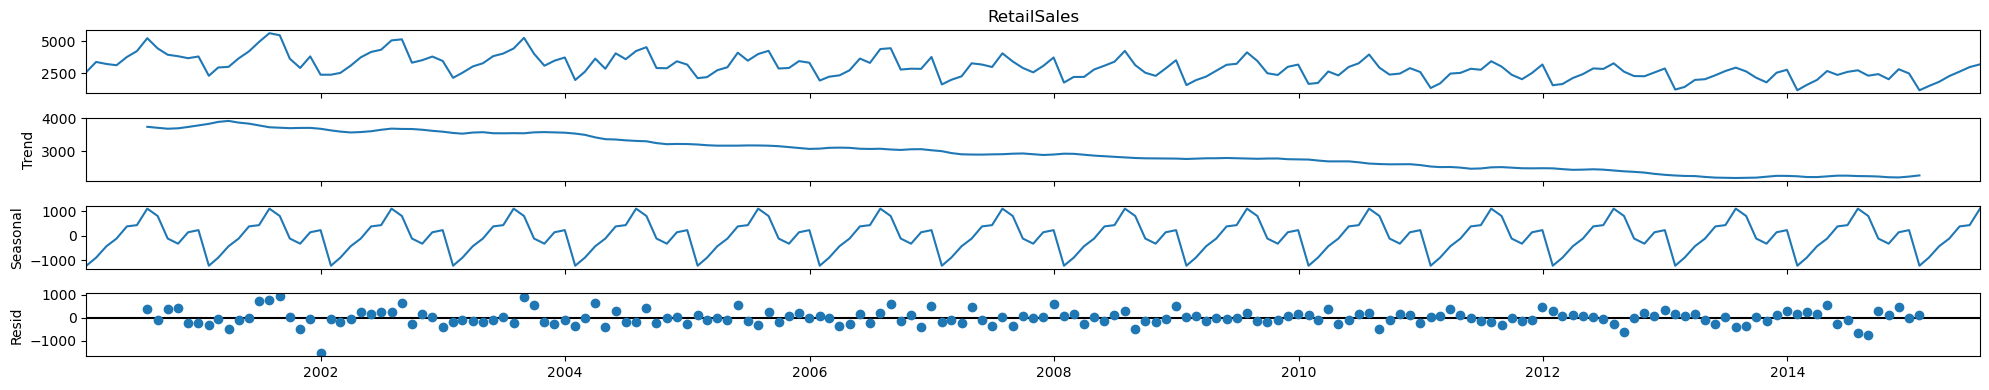

In [19]:
decomposition = seasonal_decompose(df['RetailSales'],model='additive')
decomposition.plot();

We see that the residuals are located around 0 from the plot of the residuals in the decomposition.

In [ ]:
trend = decomposition.trend
seasonality = decomposition.seasonal
residual = decomposition.resid

print('Trend','\n',trend.head(12),'\n')
print('Seasonality','\n',seasonality.head(12),'\n')
print('Residual','\n',residual.head(12),'\n')

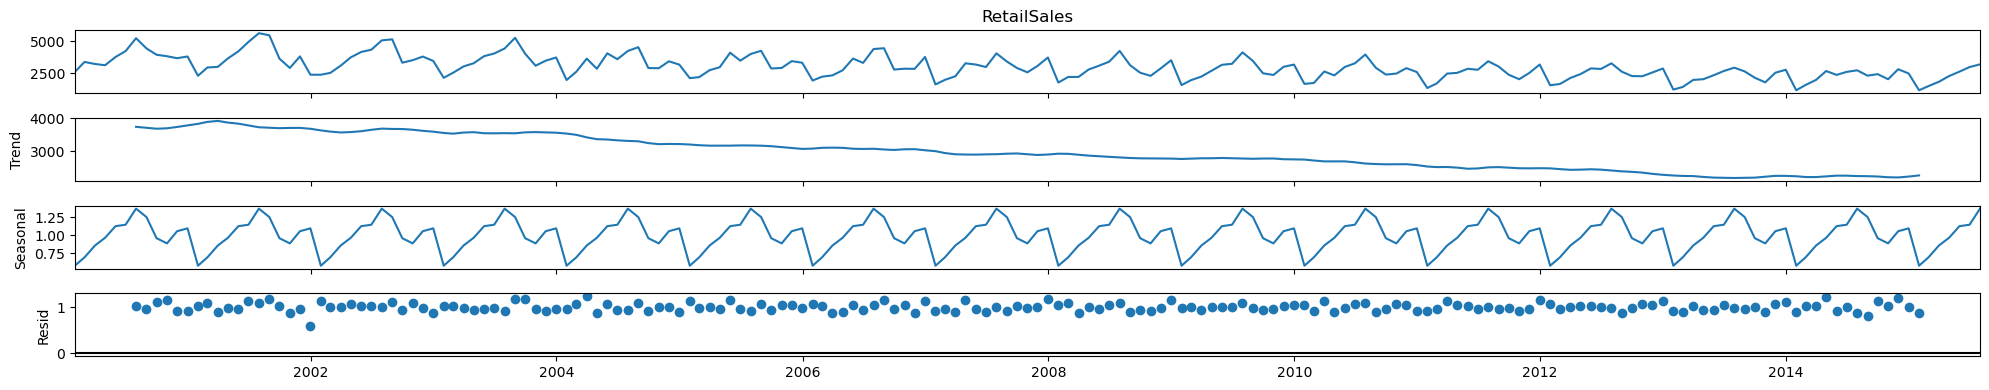

In [20]:
decomposition = seasonal_decompose(df['RetailSales'],model='multiplicative')
decomposition.plot();

For the multiplicative series, we see that a lot of residuals are located around 1.

In [ ]:
trend = decomposition.trend
seasonality = decomposition.seasonal
residual = decomposition.resid

print('Trend','\n',trend.head(12),'\n')
print('Seasonality','\n',seasonality.head(12),'\n')
print('Residual','\n',residual.head(12),'\n')

## Check for stationarity of the whole Time Series data.

In [21]:
## Test for stationarity of the series - Dicky Fuller test

from statsmodels.tsa.stattools import adfuller
def test_stationarity(timeseries):
    
    #Determing rolling statistics
    rolmean = timeseries.rolling(window=7).mean() #determining the rolling mean
    rolstd = timeseries.rolling(window=7).std()   #determining the rolling standard deviation

    #Plot rolling statistics:
    orig = plt.plot(timeseries, color='blue',label='Original')
    mean = plt.plot(rolmean, color='red', label='Rolling Mean')
    std = plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show(block=False)
    
    #Perform Dickey-Fuller test:
    print ('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print (dfoutput,'\n')

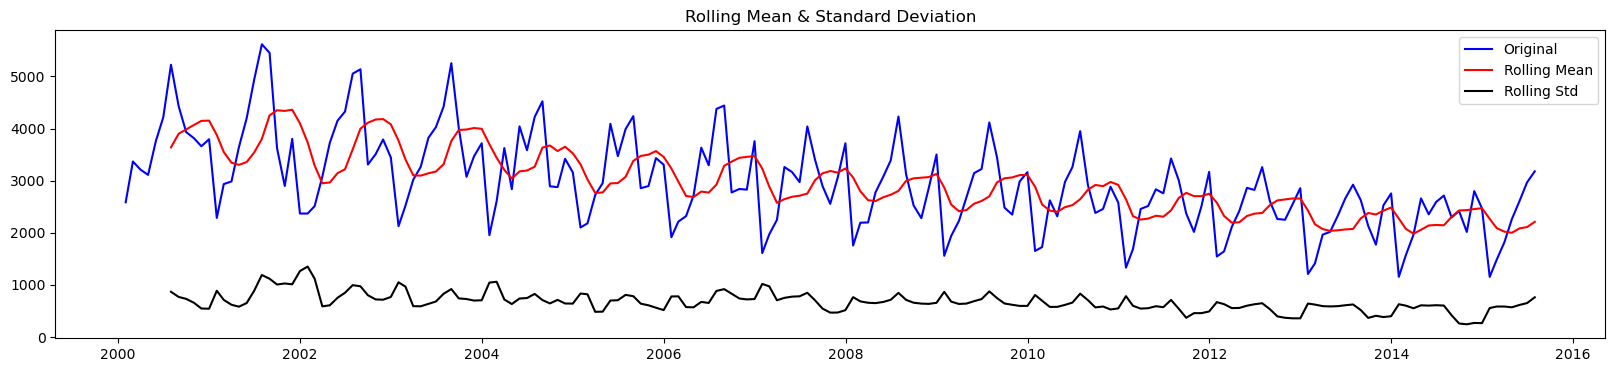

Results of Dickey-Fuller Test:
Test Statistic                  -0.907380
p-value                          0.785532
#Lags Used                      11.000000
Number of Observations Used    175.000000
Critical Value (1%)             -3.468280
Critical Value (5%)             -2.878202
Critical Value (10%)            -2.575653
dtype: float64 



In [22]:
test_stationarity(df['RetailSales'])

We see that at 5% significant level the Time Series is non-stationary.

Let us take a difference of order 1 and check whether the Time Series is stationary or not.

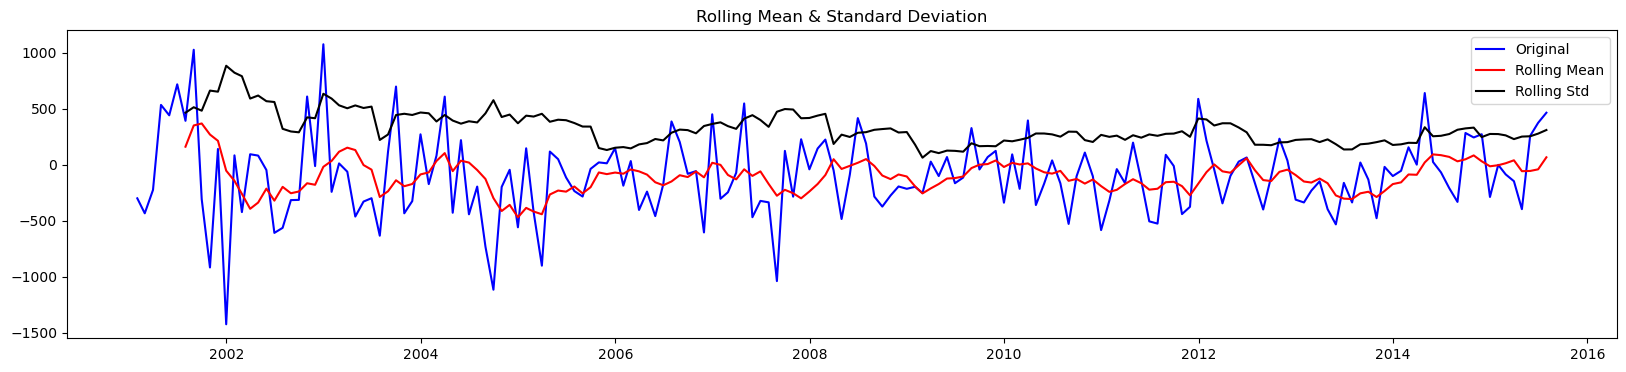

Results of Dickey-Fuller Test:
Test Statistic                  -3.773833
p-value                          0.003187
#Lags Used                      13.000000
Number of Observations Used    161.000000
Critical Value (1%)             -3.471633
Critical Value (5%)             -2.879665
Critical Value (10%)            -2.576434
dtype: float64 



In [23]:
seasonal_diff_sales = df['RetailSales'].diff(12).dropna()
test_stationarity(seasonal_diff_sales)

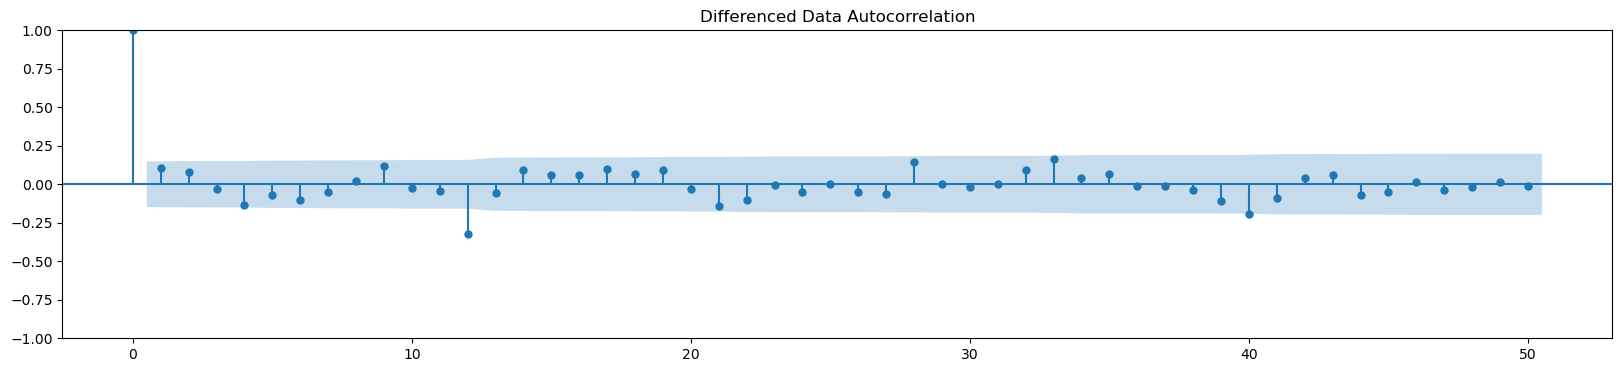

In [24]:
plot_acf(seasonal_diff_sales,lags=50,title='Differenced Data Autocorrelation')
plt.show()

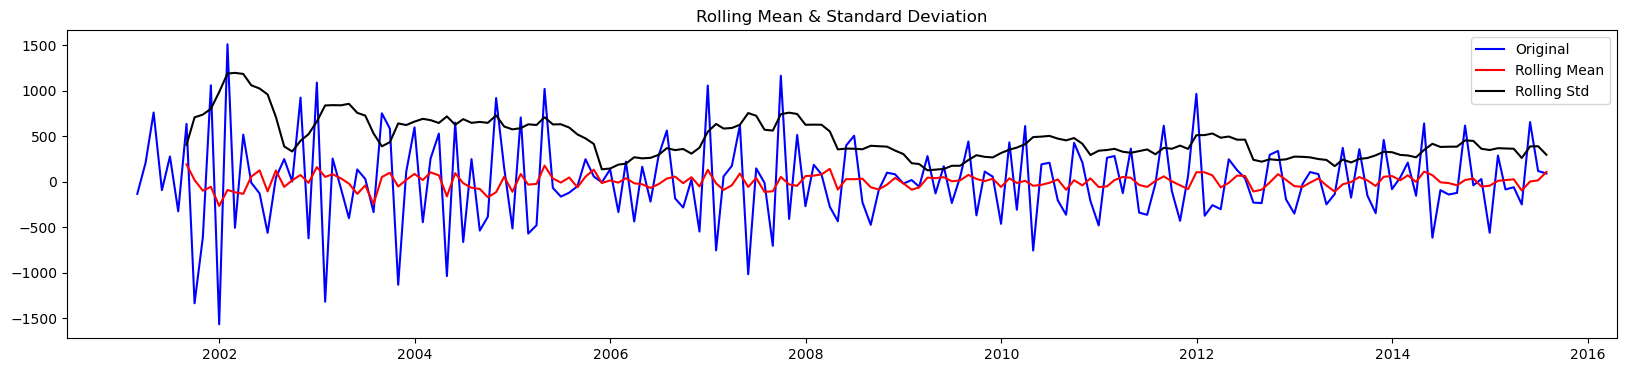

Results of Dickey-Fuller Test:
Test Statistic                -6.791484e+00
p-value                        2.358540e-09
#Lags Used                     1.300000e+01
Number of Observations Used    1.600000e+02
Critical Value (1%)           -3.471896e+00
Critical Value (5%)           -2.879780e+00
Critical Value (10%)          -2.576495e+00
dtype: float64 



In [25]:
total_diff_sales = seasonal_diff_sales.diff().dropna()
test_stationarity(total_diff_sales)

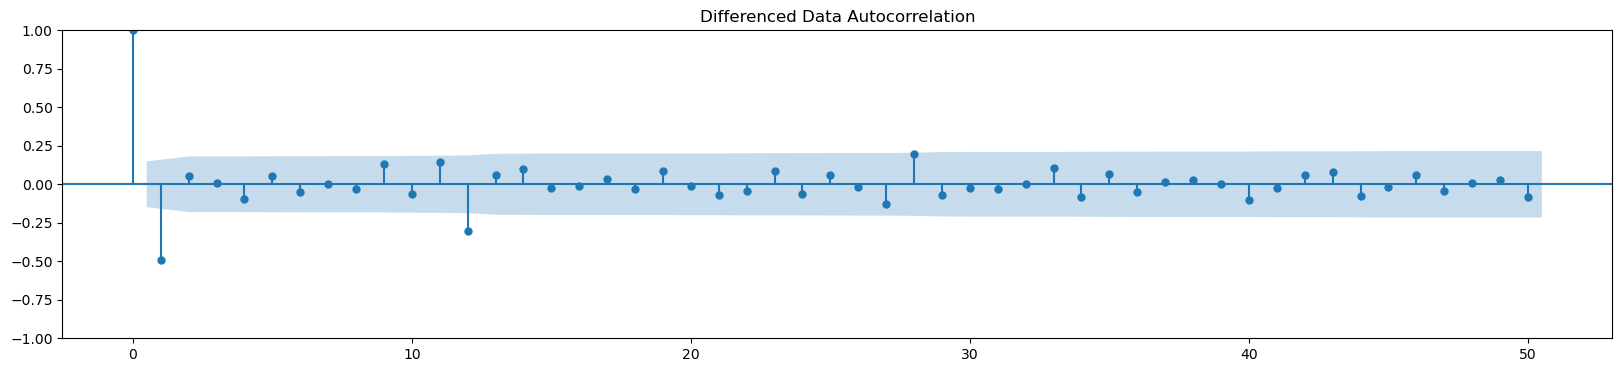

In [27]:
plot_acf(total_diff_sales,lags=50,title='Differenced Data Autocorrelation')
plt.show()

We see that at $\alpha$ = 0.05 the Time Series is indeed stationary.

In [ ]:
d = 1
D = 1

## Plot the Autocorrelation and the Partial Autocorrelation function plots on the whole data.

In [28]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

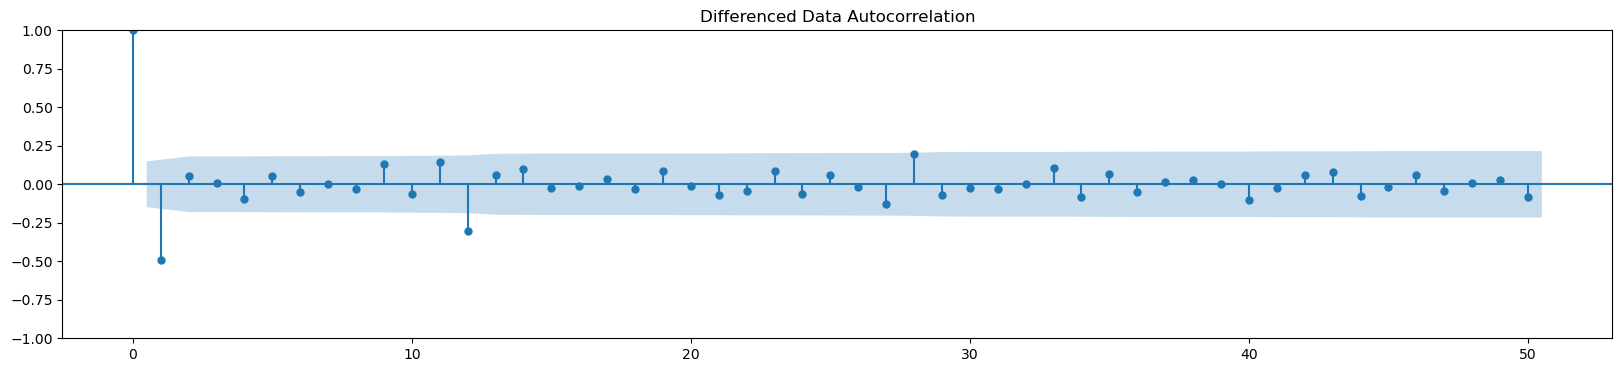

In [29]:
plot_acf(total_diff_sales,lags=50,title='Differenced Data Autocorrelation')
plt.show()

In [ ]:
q = 1
Q = 1

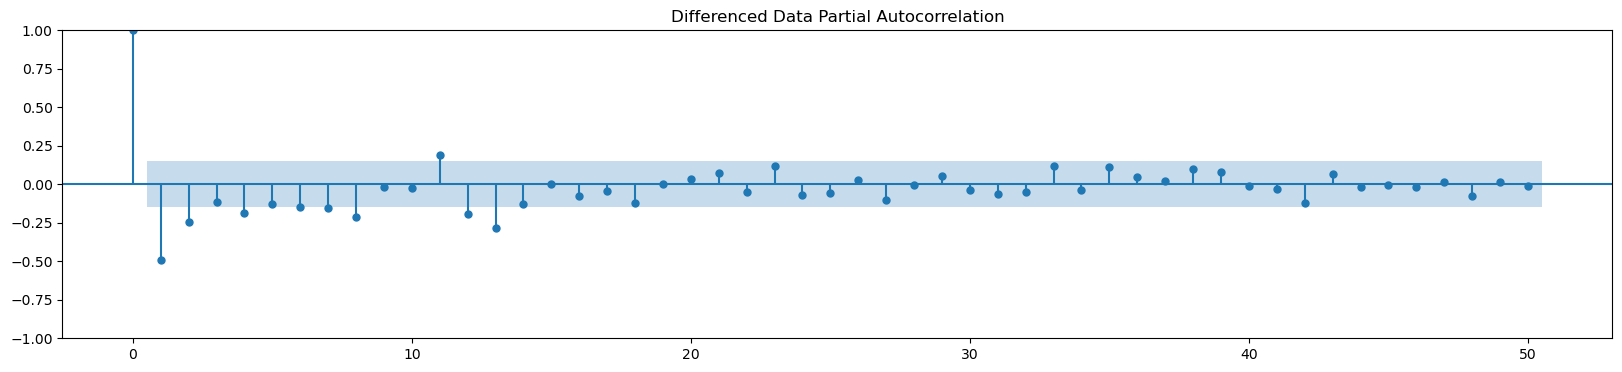

In [30]:
plot_pacf(total_diff_sales,lags=50,title='Differenced Data Partial Autocorrelation')
plt.show()

In [ ]:
p = 2 
P = 1

From the above plots, we can say that there seems to be a seasonality in the data.

## Split the data into train and test and plot the training and test data.

Training Data is till the end of 2012. Test Data is from the beginning of 2012 to the last time stamp provided.

In [31]:
train = df[df.index.year <= 2012]
test = df[df.index.year > 2012]

In [ ]:
## This is to display multiple data frames from one cell
from IPython.display import display

In [ ]:
print('First few rows of Training Data')
display(train.head())
print('Last few rows of Training Data')
display(train.tail())
print('First few rows of Test Data')
display(test.head())
print('Last few rows of Test Data')
display(test.tail())

In [32]:
print(train.shape)
print(test.shape)

(156, 1)
(31, 1)


## Build an Automated version of an ARIMA model for which the best parameters are selected in accordance with the lowest Akaike Information Criteria (AIC).

##### Note: The data has some seasonality so ideally we should build a SARIMA model. But for demonstration purposes we are building an ARIMA model both by looking at the minimum AIC criterion and by looking at the ACF and the PACF plots.

In [33]:
import pmdarima as pm
arima_model = pm.auto_arima(train,
                            start_p=1, 
                            start_q=1,
                            max_p=5, 
                            max_q=5,
                            d=1,
                            seasonal=False,
                            trace=True,
                            error_action='ignore',
                            suppress_warnings=True,
                            stepwise=True)

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.17 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2495.835, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=2495.823, Time=0.06 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=2493.977, Time=0.07 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=2493.839, Time=0.02 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.366 seconds


In [34]:
import statsmodels.api as sm
auto_ARIMA = sm.tsa.SARIMAX(train['RetailSales'], order=(0,1,0),freq='M')

results_auto_ARIMA = auto_ARIMA.fit()

print(results_auto_ARIMA.summary())

                               SARIMAX Results                                
Dep. Variable:            RetailSales   No. Observations:                  156
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -1245.920
Date:                Sat, 30 Aug 2025   AIC                           2493.839
Time:                        17:47:04   BIC                           2496.883
Sample:                    01-31-2000   HQIC                          2495.075
                         - 12-31-2012                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2       5.58e+05   5.86e+04      9.522      0.000    4.43e+05    6.73e+05
Ljung-Box (L1) (Q):                   2.37   Jarque-Bera (JB):                25.41
Prob(Q):                              0.12   Pr

C:\Users\Sreekanth\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


## Predict on the Test Set using this model and evaluate the model.

In [35]:
predicted_auto_ARIMA = results_auto_ARIMA.forecast(steps=len(test))

In [36]:
predicted_auto_ARIMA

2013-01-31    2856.0
2013-02-28    2856.0
2013-03-31    2856.0
2013-04-30    2856.0
2013-05-31    2856.0
2013-06-30    2856.0
2013-07-31    2856.0
2013-08-31    2856.0
2013-09-30    2856.0
2013-10-31    2856.0
2013-11-30    2856.0
2013-12-31    2856.0
2014-01-31    2856.0
2014-02-28    2856.0
2014-03-31    2856.0
2014-04-30    2856.0
2014-05-31    2856.0
2014-06-30    2856.0
2014-07-31    2856.0
2014-08-31    2856.0
2014-09-30    2856.0
2014-10-31    2856.0
2014-11-30    2856.0
2014-12-31    2856.0
2015-01-31    2856.0
2015-02-28    2856.0
2015-03-31    2856.0
2015-04-30    2856.0
2015-05-31    2856.0
2015-06-30    2856.0
2015-07-31    2856.0
Freq: ME, Name: predicted_mean, dtype: float64

In [37]:
from sklearn.metrics import  mean_squared_error
rmse = mean_squared_error(test['RetailSales'],predicted_auto_ARIMA,squared=False)
print(rmse)

842.1417013551165


In [38]:
resultsDf = pd.DataFrame({'RMSE': [rmse]}
                           ,index=['ARIMA(0,1,0)'])

resultsDf

,RMSE
"ARIMA(0,1,0)",842.141701


## Build a version of the ARIMA model for which the best parameters are selected by looking at the ACF and the PACF plots.

Let us look at the ACF and the PACF plots once more.

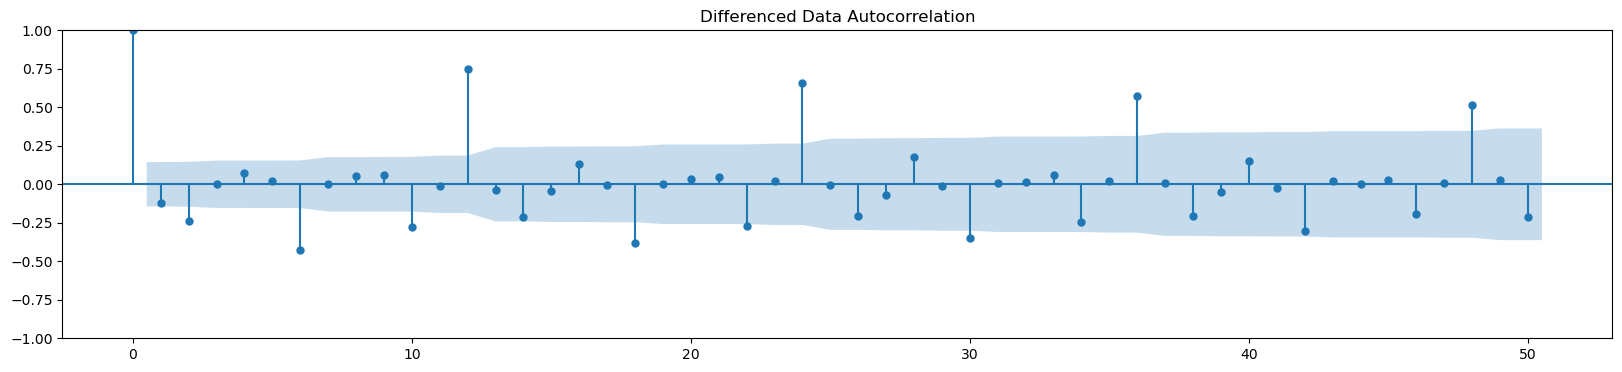

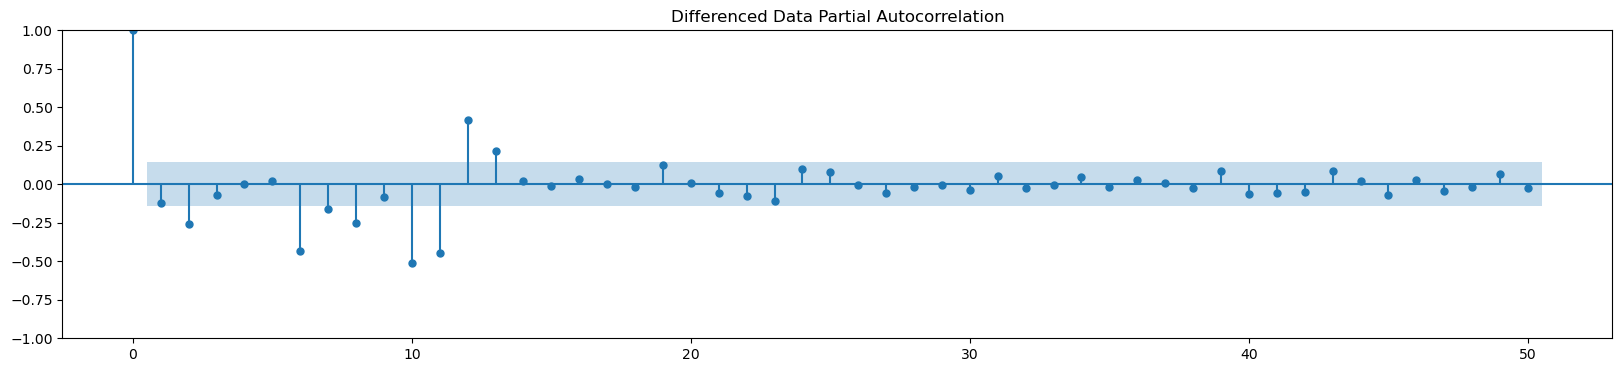

In [39]:
plot_acf(df['RetailSales'].diff().dropna(),lags=50,title='Differenced Data Autocorrelation')
plot_pacf(df['RetailSales'].diff().dropna(),lags=50,title='Differenced Data Partial Autocorrelation')
plt.show()

Here, we have taken alpha=0.05.

* The Auto-Regressive parameter in an ARIMA model is 'p' which comes from the significant lag before which the PACF plot cuts-off to 0.
* The Moving-Average parameter in an ARIMA model is 'q' which comes from the significant lag before the ACF plot cuts-off to 0.

By looking at the above plots, we can say that both the PACF and ACF plot cuts-off at lag 0.

In [40]:
manual_ARIMA = sm.tsa.SARIMAX(train['RetailSales'].astype('float64'), order=(2,1,2),freq='M')

results_manual_ARIMA = manual_ARIMA.fit()

print(results_manual_ARIMA.summary())

C:\Users\Sreekanth\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:            RetailSales   No. Observations:                  156
Model:               SARIMAX(2, 1, 2)   Log Likelihood               -1226.323
Date:                Sat, 30 Aug 2025   AIC                           2462.646
Time:                        17:49:39   BIC                           2477.863
Sample:                    01-31-2000   HQIC                          2468.827
                         - 12-31-2012                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2106      0.196     -1.076      0.282      -0.594       0.173
ar.L2          0.3158      0.131      2.417      0.016       0.060       0.572
ma.L1         -0.1182      0.144     -0.823      0.4

We get a comparatively simpler model by looking at the ACF and the PACF plots.

###### Note: When we see that both the AR(p) and the MA(q) model are of order 0, we have to convert the input variable into a 'float64' type variable else Python might throw an error.

## Predict on the Test Set using this model and evaluate the model.

In [41]:
predicted_manual_ARIMA = results_manual_ARIMA.forecast(steps=len(test))

In [42]:
rmse = mean_squared_error(test['RetailSales'],predicted_manual_ARIMA,squared=False)
print(rmse)

700.2971950598145


In [43]:
temp_resultsDf = pd.DataFrame({'RMSE': [rmse]}
                           ,index=['ARIMA(2,1,2)'])


resultsDf = pd.concat([resultsDf,temp_resultsDf])

resultsDf

,RMSE
"ARIMA(0,1,0)",842.141701
"ARIMA(2,1,2)",700.297195


We see that there is difference in the RMSE values for both the models, but remember that the second model is a much simpler model.

## Build an Automated version of a SARIMA model for which the best parameters are selected in accordance with the lowest Akaike Information Criteria (AIC).

Let us look at the ACF plot once more to understand the seasonal parameter for the SARIMA model.

### Setting the seasonality as 12 for the first iteration of the auto SARIMA model.

In [44]:
sarima_model = pm.auto_arima(train['RetailSales'],
                             start_p=1, start_q=1,
                             max_p=5, max_q=5,
                             m=12,
                             start_P=0, seasonal=True,
                             max_P=5,
                             start_Q=0,
                             max_Q=5,
                             d=1, D=1, # We've already determined these from the differencing steps
                             trace=True,
                             error_action='ignore',
                             suppress_warnings=True,
                             stepwise=True)

# Print the model summary of the best model found by auto_arima
print("\nBest SARIMA Model Summary:")
print(sarima_model.summary())

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=inf, Time=0.14 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=2190.052, Time=0.18 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=2130.656, Time=0.17 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=inf, Time=0.25 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=2152.802, Time=0.05 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=2128.197, Time=0.35 sec
 ARIMA(1,1,0)(3,1,0)[12]             : AIC=2128.327, Time=0.83 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=inf, Time=1.02 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=2123.966, Time=0.41 sec
 ARIMA(1,1,0)(0,1,1)[12]             : AIC=2122.813, Time=0.19 sec
 ARIMA(1,1,0)(0,1,2)[12]             : AIC=2124.230, Time=0.55 sec
 ARIMA(1,1,0)(1,1,2)[12]             : AIC=inf, Time=1.62 sec
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=2162.815, Time=0.19 sec
 ARIMA(2,1,0)(0,1,1)[12]             : AIC=2111.983, Time=0.34 sec
 ARIMA(2,1,0)(0,1,0)[12]             : 

In [45]:
import statsmodels.api as sm

auto_SARIMA = sm.tsa.statespace.SARIMAX(train['RetailSales'].values,
                                order=(2,1,0),
                                seasonal_order=(0,1,1,12),
                                enforce_stationarity=False,
                                enforce_invertibility=False)
results_auto_SARIMA = auto_SARIMA.fit(maxiter=1000)
print(results_auto_SARIMA.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                  156
Model:             SARIMAX(2, 1, 0)x(0, 1, [1], 12)   Log Likelihood                -943.938
Date:                              Sat, 30 Aug 2025   AIC                           1895.876
Time:                                      17:53:17   BIC                           1907.346
Sample:                                           0   HQIC                          1900.536
                                              - 156                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6393      0.079     -8.136      0.000      -0.793      -0.485
ar.L2         -0.32

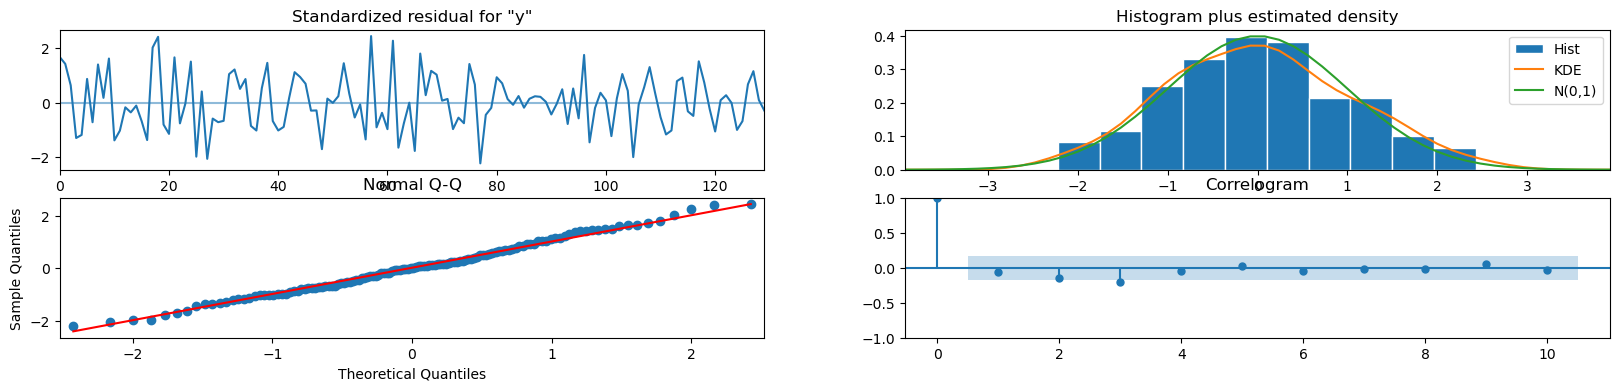

In [46]:
results_auto_SARIMA.plot_diagnostics()
plt.show()

From the model diagnostics plot, we can see that all the individual diagnostics plots almost follow the theoretical numbers and thus we cannot develop any pattern from these plots. 

## Predict on the Test Set using this model and evaluate the model.

In [47]:
predicted_auto_SARIMA = results_auto_SARIMA.get_forecast(steps=len(test))

In [48]:
predicted_auto_SARIMA.summary_frame(alpha=0.05).head()

y,mean,mean_se,mean_ci_lower,mean_ci_upper
0,1392.376559,343.482873,719.162499,2065.590618
1,1545.582292,365.141326,829.918444,2261.246141
2,2111.972206,395.410790,1336.981299,2886.963113
3,2319.420521,445.800641,1445.667322,3193.173721
4,2748.892130,474.370018,1819.143979,3678.640281


In [49]:
rmse = mean_squared_error(test['RetailSales'],predicted_auto_SARIMA.predicted_mean,squared=False)
print(rmse)

245.55676493822108


In [50]:
temp_resultsDf = pd.DataFrame({'RMSE': [rmse]}
                           ,index=['SARIMA(2,1,0)(0,1,1,12)'])


resultsDf = pd.concat([resultsDf,temp_resultsDf])

resultsDf

,RMSE
"ARIMA(0,1,0)",842.141701
"ARIMA(2,1,2)",700.297195
"SARIMA(2,1,0)(0,1,1,12)",245.556765


We see that we have huge gain the RMSE value by including the seasonal parameters as well.

## Build a version of the SARIMA model for which the best parameters are selected by looking at the ACF and the PACF plots. - Seasonality at 6.

Let us look at the ACF and the PACF plots once more.

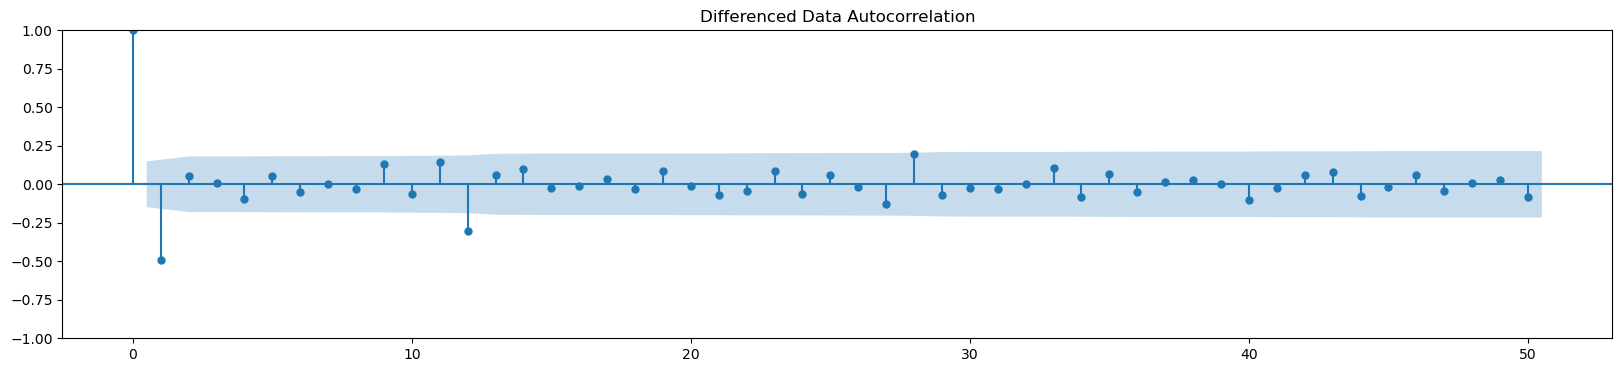

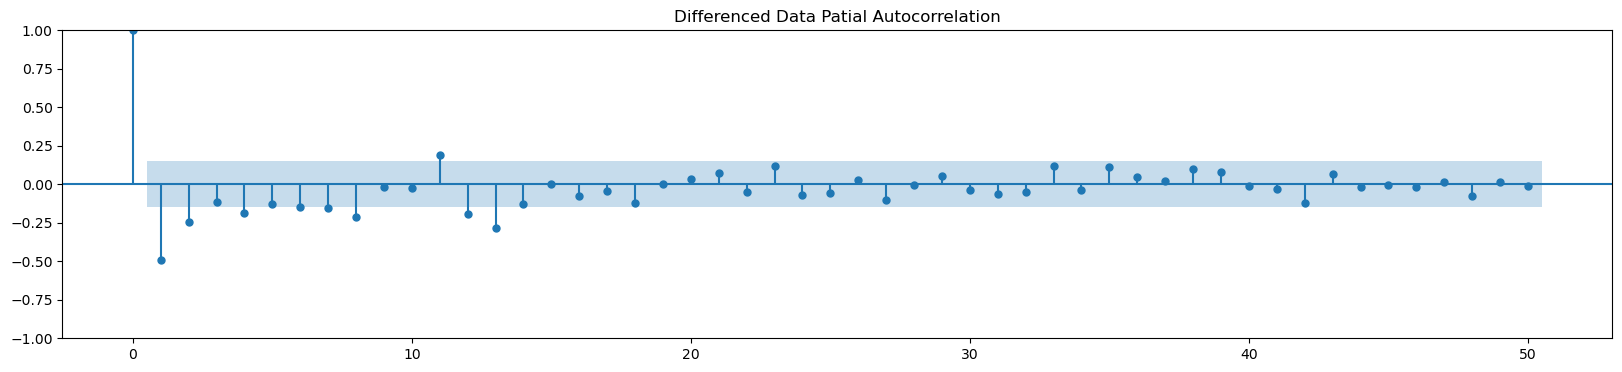

In [51]:
plot_acf(total_diff_sales,lags=50,title='Differenced Data Autocorrelation')
plot_pacf(total_diff_sales,lags=50,title='Differenced Data Patial Autocorrelation')
plt.show()

Please do refer to $\href{https://online.stat.psu.edu/stat510/lesson/4/4.1}{this\ link}$ to read more about Seasonal Auto-Regressive Integrtaed Moving Average Models.

In [52]:
import statsmodels.api as sm

manual_SARIMA = sm.tsa.statespace.SARIMAX(train['RetailSales'].values,
                                order=(2, 1, 1),
                                seasonal_order=(1, 1, 1, 12),
                                enforce_stationarity=False,
                                enforce_invertibility=False)
results_manual_SARIMA = manual_SARIMA.fit(maxiter=1000)
print(results_manual_SARIMA.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  156
Model:             SARIMAX(2, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -918.560
Date:                            Sat, 30 Aug 2025   AIC                           1849.119
Time:                                    17:56:42   BIC                           1866.278
Sample:                                         0   HQIC                          1856.091
                                            - 156                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0160      0.088      0.182      0.856      -0.157       0.189
ar.L2         -0.0396      0.093   

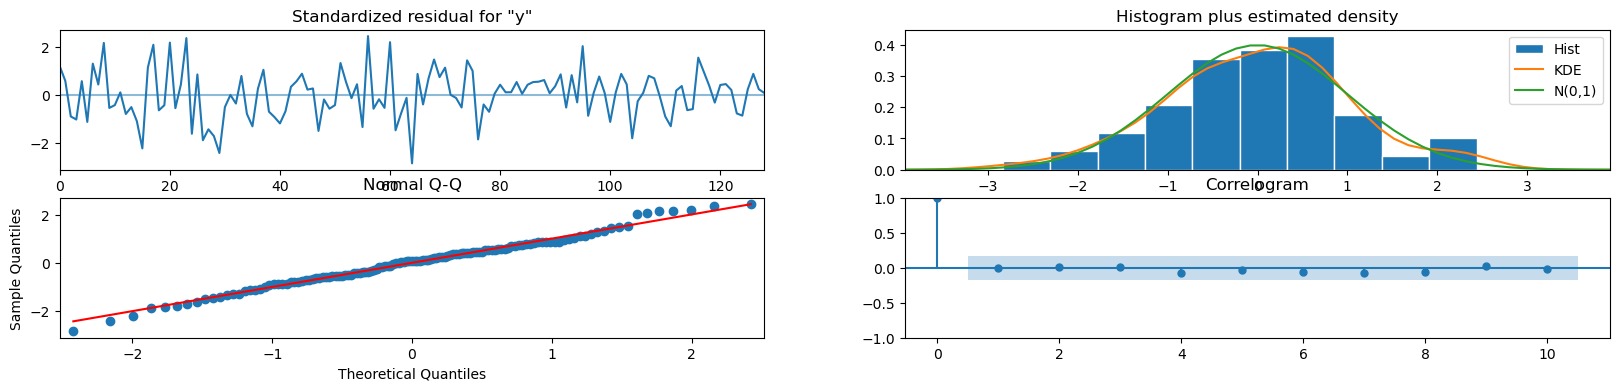

In [53]:
results_manual_SARIMA.plot_diagnostics()
plt.show()

The model diagnostics plot looks okay.

## Predict on the Test Set using this model and evaluate the model.

In [54]:
predicted_manual_SARIMA = results_manual_SARIMA.get_forecast(steps=len(test))

In [55]:
predicted_manual_SARIMA.summary_frame(alpha=0.05).head()

y,mean,mean_se,mean_ci_lower,mean_ci_upper
0,1283.986888,295.418101,704.978050,1862.995726
1,1476.219996,295.496914,897.056688,2055.383305
2,2037.815816,295.624846,1458.401765,2617.229867
3,2237.456779,295.621957,1658.048389,2816.865168
4,2676.489853,295.626091,2097.073362,3255.906344


In [56]:
rmse = mean_squared_error(test['RetailSales'],predicted_manual_SARIMA.predicted_mean,squared=False)
print(rmse)

251.217531924448


In [57]:
temp_resultsDf = pd.DataFrame({'RMSE': [rmse]}
                           ,index=['SARIMA(2,1,1)(1,1,1,12)'])


resultsDf = pd.concat([resultsDf,temp_resultsDf])

resultsDf

,RMSE
"ARIMA(0,1,0)",842.141701
"ARIMA(2,1,2)",700.297195
"SARIMA(2,1,0)(0,1,1,12)",245.556765
"SARIMA(2,1,1)(1,1,1,12)",251.217532


This is where our model building exercise ends. 

Please do try out with 12 as a seasonal parameter and check whether that gives you a better RMSE value. Also, try taking different kinds of transformations as well.

Now, we will take our best model and forecast 12 months into the future with appropriate confidence intervals to see how the predictions look. We have to build our model on the full data for this.

## Building the most optimum model on the Full Data.

In [58]:
full_data_model = sm.tsa.statespace.SARIMAX(df['RetailSales'],
                                order=(2, 1, 1),
                                seasonal_order=(1, 1, 1, 12),
                                enforce_stationarity=False,
                                enforce_invertibility=False)
results_full_data_model = full_data_model.fit(maxiter=1000)
print(results_full_data_model.summary())

C:\Users\Sreekanth\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\Sreekanth\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                        RetailSales   No. Observations:                  187
Model:             SARIMAX(2, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -1134.996
Date:                            Sat, 30 Aug 2025   AIC                           2281.992
Time:                                    17:58:17   BIC                           2300.443
Sample:                                01-31-2000   HQIC                          2289.484
                                     - 07-31-2015                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0585      0.083      0.705      0.481      -0.104       0.221
ar.L2         -0.0015      0.085   

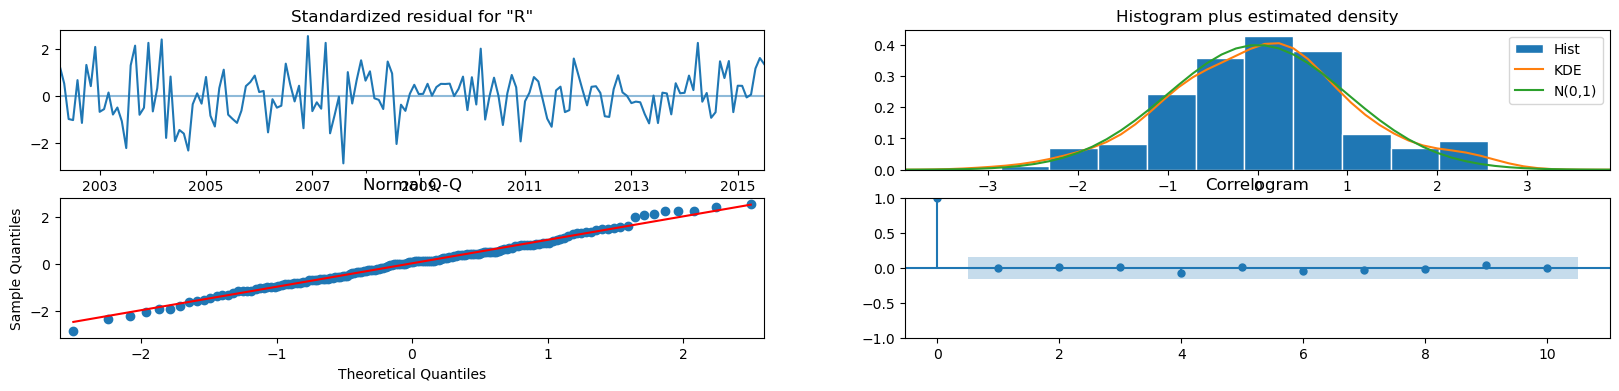

In [59]:
results_full_data_model.plot_diagnostics();

## Evaluate the model on the whole and predict 17 months into the future (till the end of next year).

In [60]:
predicted_manual_SARIMA_full_data = results_full_data_model.get_forecast(steps=17)

In [61]:
predicted_manual_SARIMA_full_data.summary_frame(alpha=0.05).head()

RetailSales,mean,mean_se,mean_ci_lower,mean_ci_upper
2015-08-31,2341.049042,288.653493,1775.298592,2906.799493
2015-09-30,2135.534218,289.481577,1568.160753,2702.907682
2015-10-31,1817.166726,289.539457,1249.679818,2384.653634
2015-11-30,2496.393477,289.586825,1928.813730,3063.973224
2015-12-31,2461.811001,289.634034,1894.138725,3029.483276


In [62]:
rmse = mean_squared_error(df['RetailSales'],results_full_data_model.fittedvalues,squared=False)
print('RMSE of the Full Model',rmse)

RMSE of the Full Model 465.15167996058653


In [63]:
pred_full_manual_SARIMA_date = predicted_manual_SARIMA_full_data.summary_frame(alpha=0.05).set_index(pd.date_range(start='2015-08-31',end='2016-12-31', freq='M'))

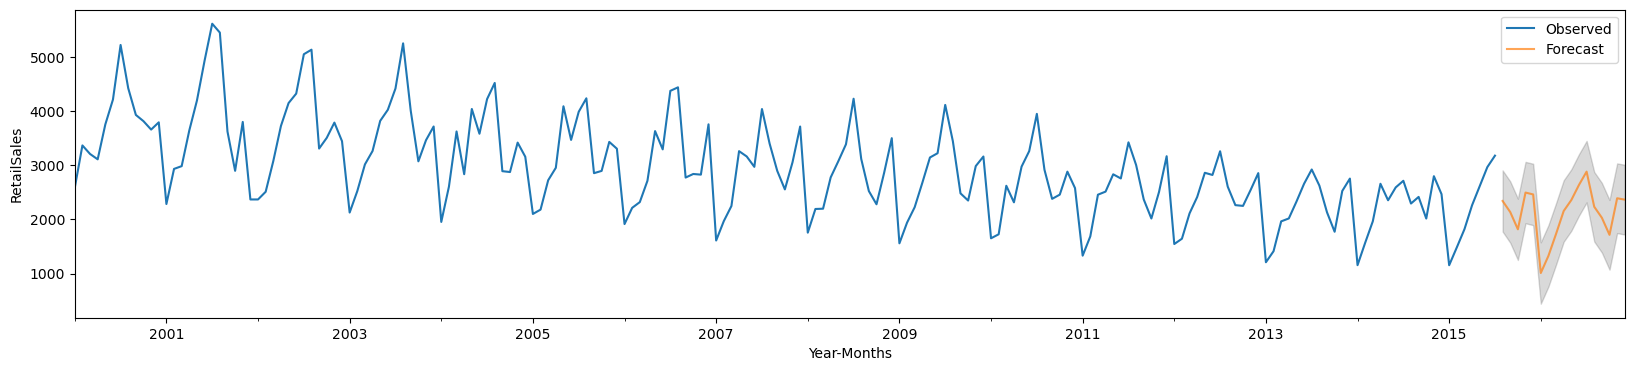

In [64]:
# plot the forecast along with the confidence band

axis = df['RetailSales'].plot(label='Observed')
pred_full_manual_SARIMA_date['mean'].plot(ax=axis, label='Forecast', alpha=0.7)
axis.fill_between(pred_full_manual_SARIMA_date.index, pred_full_manual_SARIMA_date['mean_ci_lower'], 
                  pred_full_manual_SARIMA_date['mean_ci_upper'], color='k', alpha=.15)
axis.set_xlabel('Year-Months')
axis.set_ylabel('RetailSales')
plt.legend(loc='best')
plt.show()

In [65]:
resultsDf

,RMSE
"ARIMA(0,1,0)",842.141701
"ARIMA(2,1,2)",700.297195
"SARIMA(2,1,0)(0,1,1,12)",245.556765
"SARIMA(2,1,1)(1,1,1,12)",251.217532


# END